In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from astral.sun import sun
from astral import LocationInfo
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# 1. Load Cleaned Data

In [2]:
df_cleaned = pd.read_csv('../data/cleaned_data.csv')
df_cleaned['Timestamp'] = pd.to_datetime(df_cleaned['Timestamp'], errors='coerce')
df_cleaned.shape

(5832, 22)

In [3]:
df_cleaned.head()

,Timestamp,PV1_Current_A,PV2_Current_A,PV1_Voltage_V,PV2_Voltage_V,PV1_Power_W,PV2_Power_W,DC,Solar_Radiation_Wm2,Outdoor_Temp_C,...,Wind_Dir_deg,Pressure_hPa,Humidity_pct,UV_Index,Wind_Gust_ms,Rain_mm,AQI_US,PM25_ugm3,PM10_ugm3,PM1_ugm3
0,2026-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.192,...,293.500,1015.973,72.833,0.0,1.5,0.0,52.550,10.500,18.850,8.167
1,2026-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.008,...,320.083,1016.199,73.917,0.0,1.0,0.0,46.517,8.433,14.950,6.550
2,2026-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.875,...,321.000,1016.594,75.750,0.0,1.0,0.0,46.383,8.433,15.017,6.417
3,2026-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.367,...,321.000,1016.764,77.833,0.0,1.0,0.0,51.800,9.617,17.317,7.567
4,2026-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,8.925,...,321.583,1016.679,79.833,0.0,1.5,0.0,52.767,9.983,17.033,8.033


# 2. Preprocessing

Applies the treatment decisions motivated by the Diagnostic EDA notebook: restrict to daylight hours, then impute remaining gaps.

## Filter to Overall Date Range

In [4]:
start_date = '2026-01-01 00:00:00'
end_date = '2026-08-31 23:00:00'

mask = (df_cleaned['Timestamp'] >= start_date) & (df_cleaned['Timestamp'] <= end_date)
df_cleaned = df_cleaned.loc[mask].copy()
print(f"Filtered data to be between {start_date} and {end_date}. New shape: {df_cleaned.shape}")

Filtered data to be between 2026-01-01 00:00:00 and 2026-08-31 23:00:00. New shape: (5832, 22)


## Filter to Daytime Hours (Sunrise–Sunset)

Using the diagnostic boxplot's finding that AC output is negligible/noisy outside daylight, we compute actual sunrise/sunset times for the plant's location and keep only daytime rows.

In [5]:
df_filtered = df_cleaned.copy()

location = LocationInfo("Sfax", "Tunisia", "Africa/Tunis", 34.7167, 10.6833)
print("Location defined for Sfax, Tunisia.")

if 'Timestamp' in df_filtered.columns:
    df_filtered.set_index('Timestamp', inplace=True)

df_filtered.index = df_filtered.index.tz_localize('Africa/Tunis')
print("Localized the time index to 'Africa/Tunis' to match sunrise/sunset calculations.")

def is_daytime(row):
    s = sun(location.observer, date=row.date(), tzinfo=location.timezone)
    return s['sunrise'] <= row <= s['sunset']

daytime_mask = df_filtered.index.to_series().apply(is_daytime)
df_filtered = df_filtered[daytime_mask].copy()
print(f"Filtered for daytime hours only. Shape changed from {df_cleaned.shape} to {df_filtered.shape}.")

df_filtered.index = df_filtered.index.tz_convert(None)
df_filtered.reset_index(inplace=True)

Location defined for Sfax, Tunisia.
Localized the time index to 'Africa/Tunis' to match sunrise/sunset calculations.
Filtered for daytime hours only. Shape changed from (5832, 22) to (3084, 21).


### Verify: AC Power by Hour of Day After Filtering

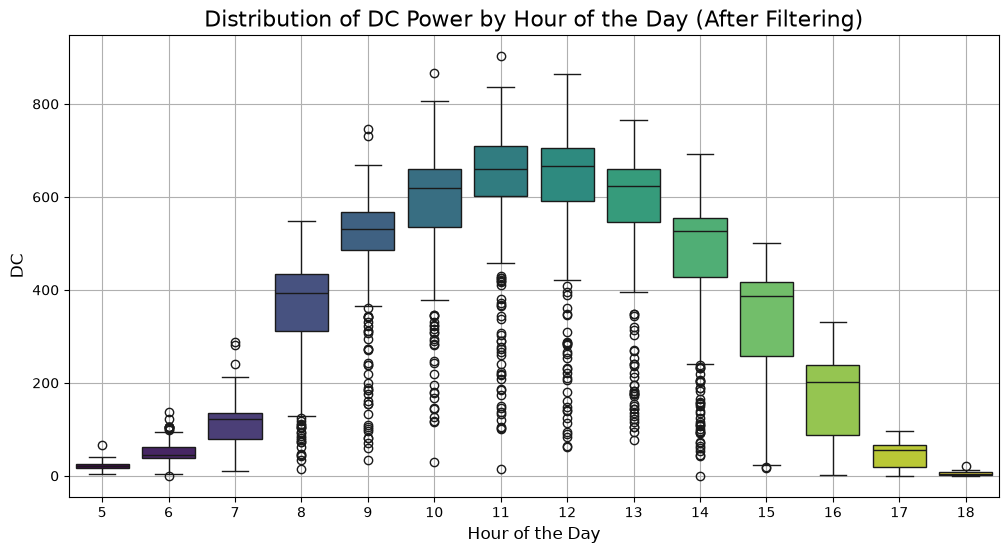

In [6]:
os.makedirs('../figures', exist_ok=True)

df_filtered['Hour_of_Day'] = df_filtered['Timestamp'].dt.hour

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Hour_of_Day',
    y='DC',
    hue='Hour_of_Day',
    data=df_filtered,
    palette='viridis',
    legend=False
)
plt.title('Distribution of DC Power by Hour of the Day (After Filtering)', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('DC', fontsize=12)
plt.grid(True)
plt.savefig('../figures/Distribution_of_DC_Power_by_Hour_of_the_Day_After_Filtering.png',
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

df_filtered.drop(columns=['Hour_of_Day'], inplace=True)

## Save filtered data

In [7]:
df_filtered.to_csv("../data/filtered_data.csv", index=False)

In [8]:
df_filtered.shape

(3084, 22)

## Missing Values in Filtered Data

In [9]:
df_filtered.set_index('Timestamp', inplace=True)
missing_values = df_filtered.isnull().sum()
print(missing_values)

PV1_Current_A          65
PV2_Current_A          65
PV1_Voltage_V          65
PV2_Voltage_V          65
PV1_Power_W            80
PV2_Power_W            80
DC                     80
Solar_Radiation_Wm2     0
Outdoor_Temp_C          0
Dew_Point_C             0
Wind_Speed_ms           0
Wind_Dir_deg            0
Pressure_hPa            0
Humidity_pct            0
UV_Index                0
Wind_Gust_ms            0
Rain_mm                 0
AQI_US                 22
PM25_ugm3              22
PM10_ugm3              22
PM1_ugm3               22
dtype: int64


### Handling Missing power data with voltage 

#### Find out if PV1_Power_W and PV2_Power_W are null when current and voltage are not null


In [10]:
# PV1
pv1_recoverable = df_filtered["PV1_Power_W"].isna() & df_filtered["PV1_Current_A"].notna() & df_filtered["PV1_Voltage_V"].notna()
print(f"PV1: {pv1_recoverable.sum()} rows where power is missing but current & voltage are available")

# PV2
pv2_recoverable = df_filtered["PV2_Power_W"].isna() & df_filtered["PV2_Current_A"].notna() & df_filtered["PV2_Voltage_V"].notna()
print(f"PV2: {pv2_recoverable.sum()} rows where power is missing but current & voltage are available")

PV1: 15 rows where power is missing but current & voltage are available
PV2: 15 rows where power is missing but current & voltage are available


In [11]:
df_filtered.columns

Index(['PV1_Current_A', 'PV2_Current_A', 'PV1_Voltage_V', 'PV2_Voltage_V',
       'PV1_Power_W', 'PV2_Power_W', 'DC', 'Solar_Radiation_Wm2',
       'Outdoor_Temp_C', 'Dew_Point_C', 'Wind_Speed_ms', 'Wind_Dir_deg',
       'Pressure_hPa', 'Humidity_pct', 'UV_Index', 'Wind_Gust_ms', 'Rain_mm',
       'AQI_US', 'PM25_ugm3', 'PM10_ugm3', 'PM1_ugm3'],
      dtype='str')

In [12]:
df_filtered.loc[pv1_recoverable, "PV1_Power_W"] = (
df_filtered.loc[pv1_recoverable, "PV1_Voltage_V"] * df_filtered.loc[pv1_recoverable, "PV1_Current_A"]
)

df_filtered.loc[pv2_recoverable, "PV2_Power_W"] = (
df_filtered.loc[pv2_recoverable, "PV2_Voltage_V"] * df_filtered.loc[pv2_recoverable, "PV2_Current_A"]
)

# Only fill PV_Total_Power_W where it is missing — do not overwrite existing valid totals
df_filtered["DC"] = df_filtered["DC"].fillna(df_filtered["PV1_Power_W"] + df_filtered["PV2_Power_W"])

In [13]:
# Check using the same code

# PV1
pv1_recoverable = df_filtered["PV1_Power_W"].isna() & df_filtered["PV1_Current_A"].notna() & df_filtered["PV1_Voltage_V"].notna()
print(f"PV1: {pv1_recoverable.sum()} rows where power is missing but current & voltage are available")

# PV2
pv2_recoverable = df_filtered["PV2_Power_W"].isna() & df_filtered["PV2_Current_A"].notna() & df_filtered["PV2_Voltage_V"].notna()
print(f"PV2: {pv2_recoverable.sum()} rows where power is missing but current & voltage are available")

PV1: 0 rows where power is missing but current & voltage are available
PV2: 0 rows where power is missing but current & voltage are available


In [14]:
missing_values = df_filtered.isnull().sum()
print(missing_values)

PV1_Current_A          65
PV2_Current_A          65
PV1_Voltage_V          65
PV2_Voltage_V          65
PV1_Power_W            65
PV2_Power_W            65
DC                     65
Solar_Radiation_Wm2     0
Outdoor_Temp_C          0
Dew_Point_C             0
Wind_Speed_ms           0
Wind_Dir_deg            0
Pressure_hPa            0
Humidity_pct            0
UV_Index                0
Wind_Gust_ms            0
Rain_mm                 0
AQI_US                 22
PM25_ugm3              22
PM10_ugm3              22
PM1_ugm3               22
dtype: int64


### Remove unecessary columns

In [15]:
# Drop columns that are not needed for the analysis we will only use DC which represents the total power from both PV1 and PV2. The individual PV columns are not needed for further analysis.
cols_to_drop = [
 'PV1_Current_A', 'PV2_Current_A', 'PV1_Voltage_V', 'PV2_Voltage_V',
 'PV1_Power_W', 'PV2_Power_W'
]

existing_cols_to_drop = [c for c in cols_to_drop if c in df_filtered.columns]
missing_cols_to_drop = [c for c in cols_to_drop if c not in df_filtered.columns]

df_filtered.drop(columns=existing_cols_to_drop, inplace=True)

print(f"Dropped {len(existing_cols_to_drop)} columns:")
print(existing_cols_to_drop)
if missing_cols_to_drop:
    print("Not found in df (already absent):", missing_cols_to_drop)
print(f"New shape: {df_filtered.shape}")


Dropped 6 columns:
['PV1_Current_A', 'PV2_Current_A', 'PV1_Voltage_V', 'PV2_Voltage_V', 'PV1_Power_W', 'PV2_Power_W']
New shape: (3084, 15)


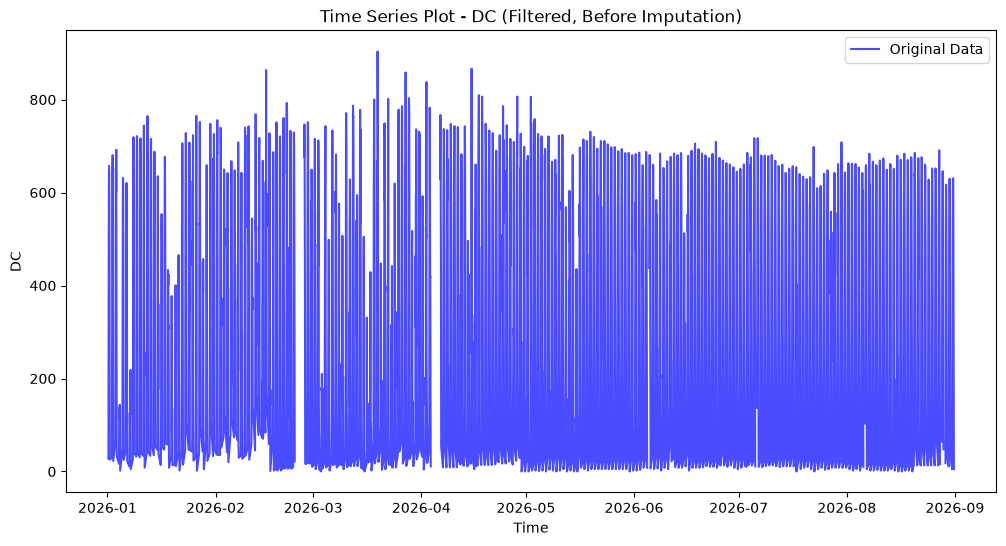

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df_filtered.index, df_filtered['DC'], label="Original Data", color="blue", alpha=0.7)
plt.xlabel("Time")
plt.ylabel('DC')
plt.title("Time Series Plot - DC (Filtered, Before Imputation)")
plt.legend()
plt.show()

# 3. Imputation of Missing Values Using KNN

In [17]:
print("--- Starting Imputation Process ---")
print("Initial missing values")
print(df_filtered.isnull().sum())

# Scale first so KNN's distance metric isn't dominated by large-magnitude columns
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_filtered)

imputer = KNNImputer(n_neighbors=5)
imputed_scaled = imputer.fit_transform(scaled_values)

imputed_data = scaler.inverse_transform(imputed_scaled)
df_imputed = pd.DataFrame(imputed_data, columns=df_filtered.columns, index=df_filtered.index)

print("Imputation complete.")
print(df_imputed.isnull().sum())

--- Starting Imputation Process ---
Initial missing values
DC                     65
Solar_Radiation_Wm2     0
Outdoor_Temp_C          0
Dew_Point_C             0
Wind_Speed_ms           0
Wind_Dir_deg            0
Pressure_hPa            0
Humidity_pct            0
UV_Index                0
Wind_Gust_ms            0
Rain_mm                 0
AQI_US                 22
PM25_ugm3              22
PM10_ugm3              22
PM1_ugm3               22
dtype: int64
Imputation complete.
DC                     0
Solar_Radiation_Wm2    0
Outdoor_Temp_C         0
Dew_Point_C            0
Wind_Speed_ms          0
Wind_Dir_deg           0
Pressure_hPa           0
Humidity_pct           0
UV_Index               0
Wind_Gust_ms           0
Rain_mm                0
AQI_US                 0
PM25_ugm3              0
PM10_ugm3              0
PM1_ugm3               0
dtype: int64


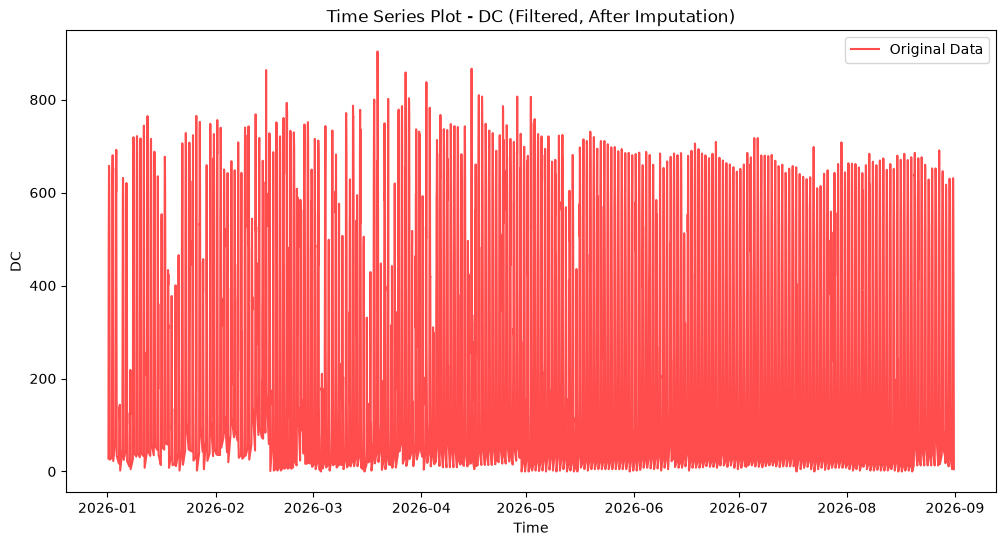

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df_imputed.index, df_imputed['DC'], label="Original Data", color="red", alpha=0.7)
plt.xlabel("Time")
plt.ylabel('DC')
plt.title("Time Series Plot - DC (Filtered, After Imputation)")
plt.legend()
plt.show()

## Compare Original vs Imputed

Creating grid comparison plot for columns with imputed values: ['DC', 'AQI_US', 'PM25_ugm3', 'PM10_ugm3', 'PM1_ugm3']


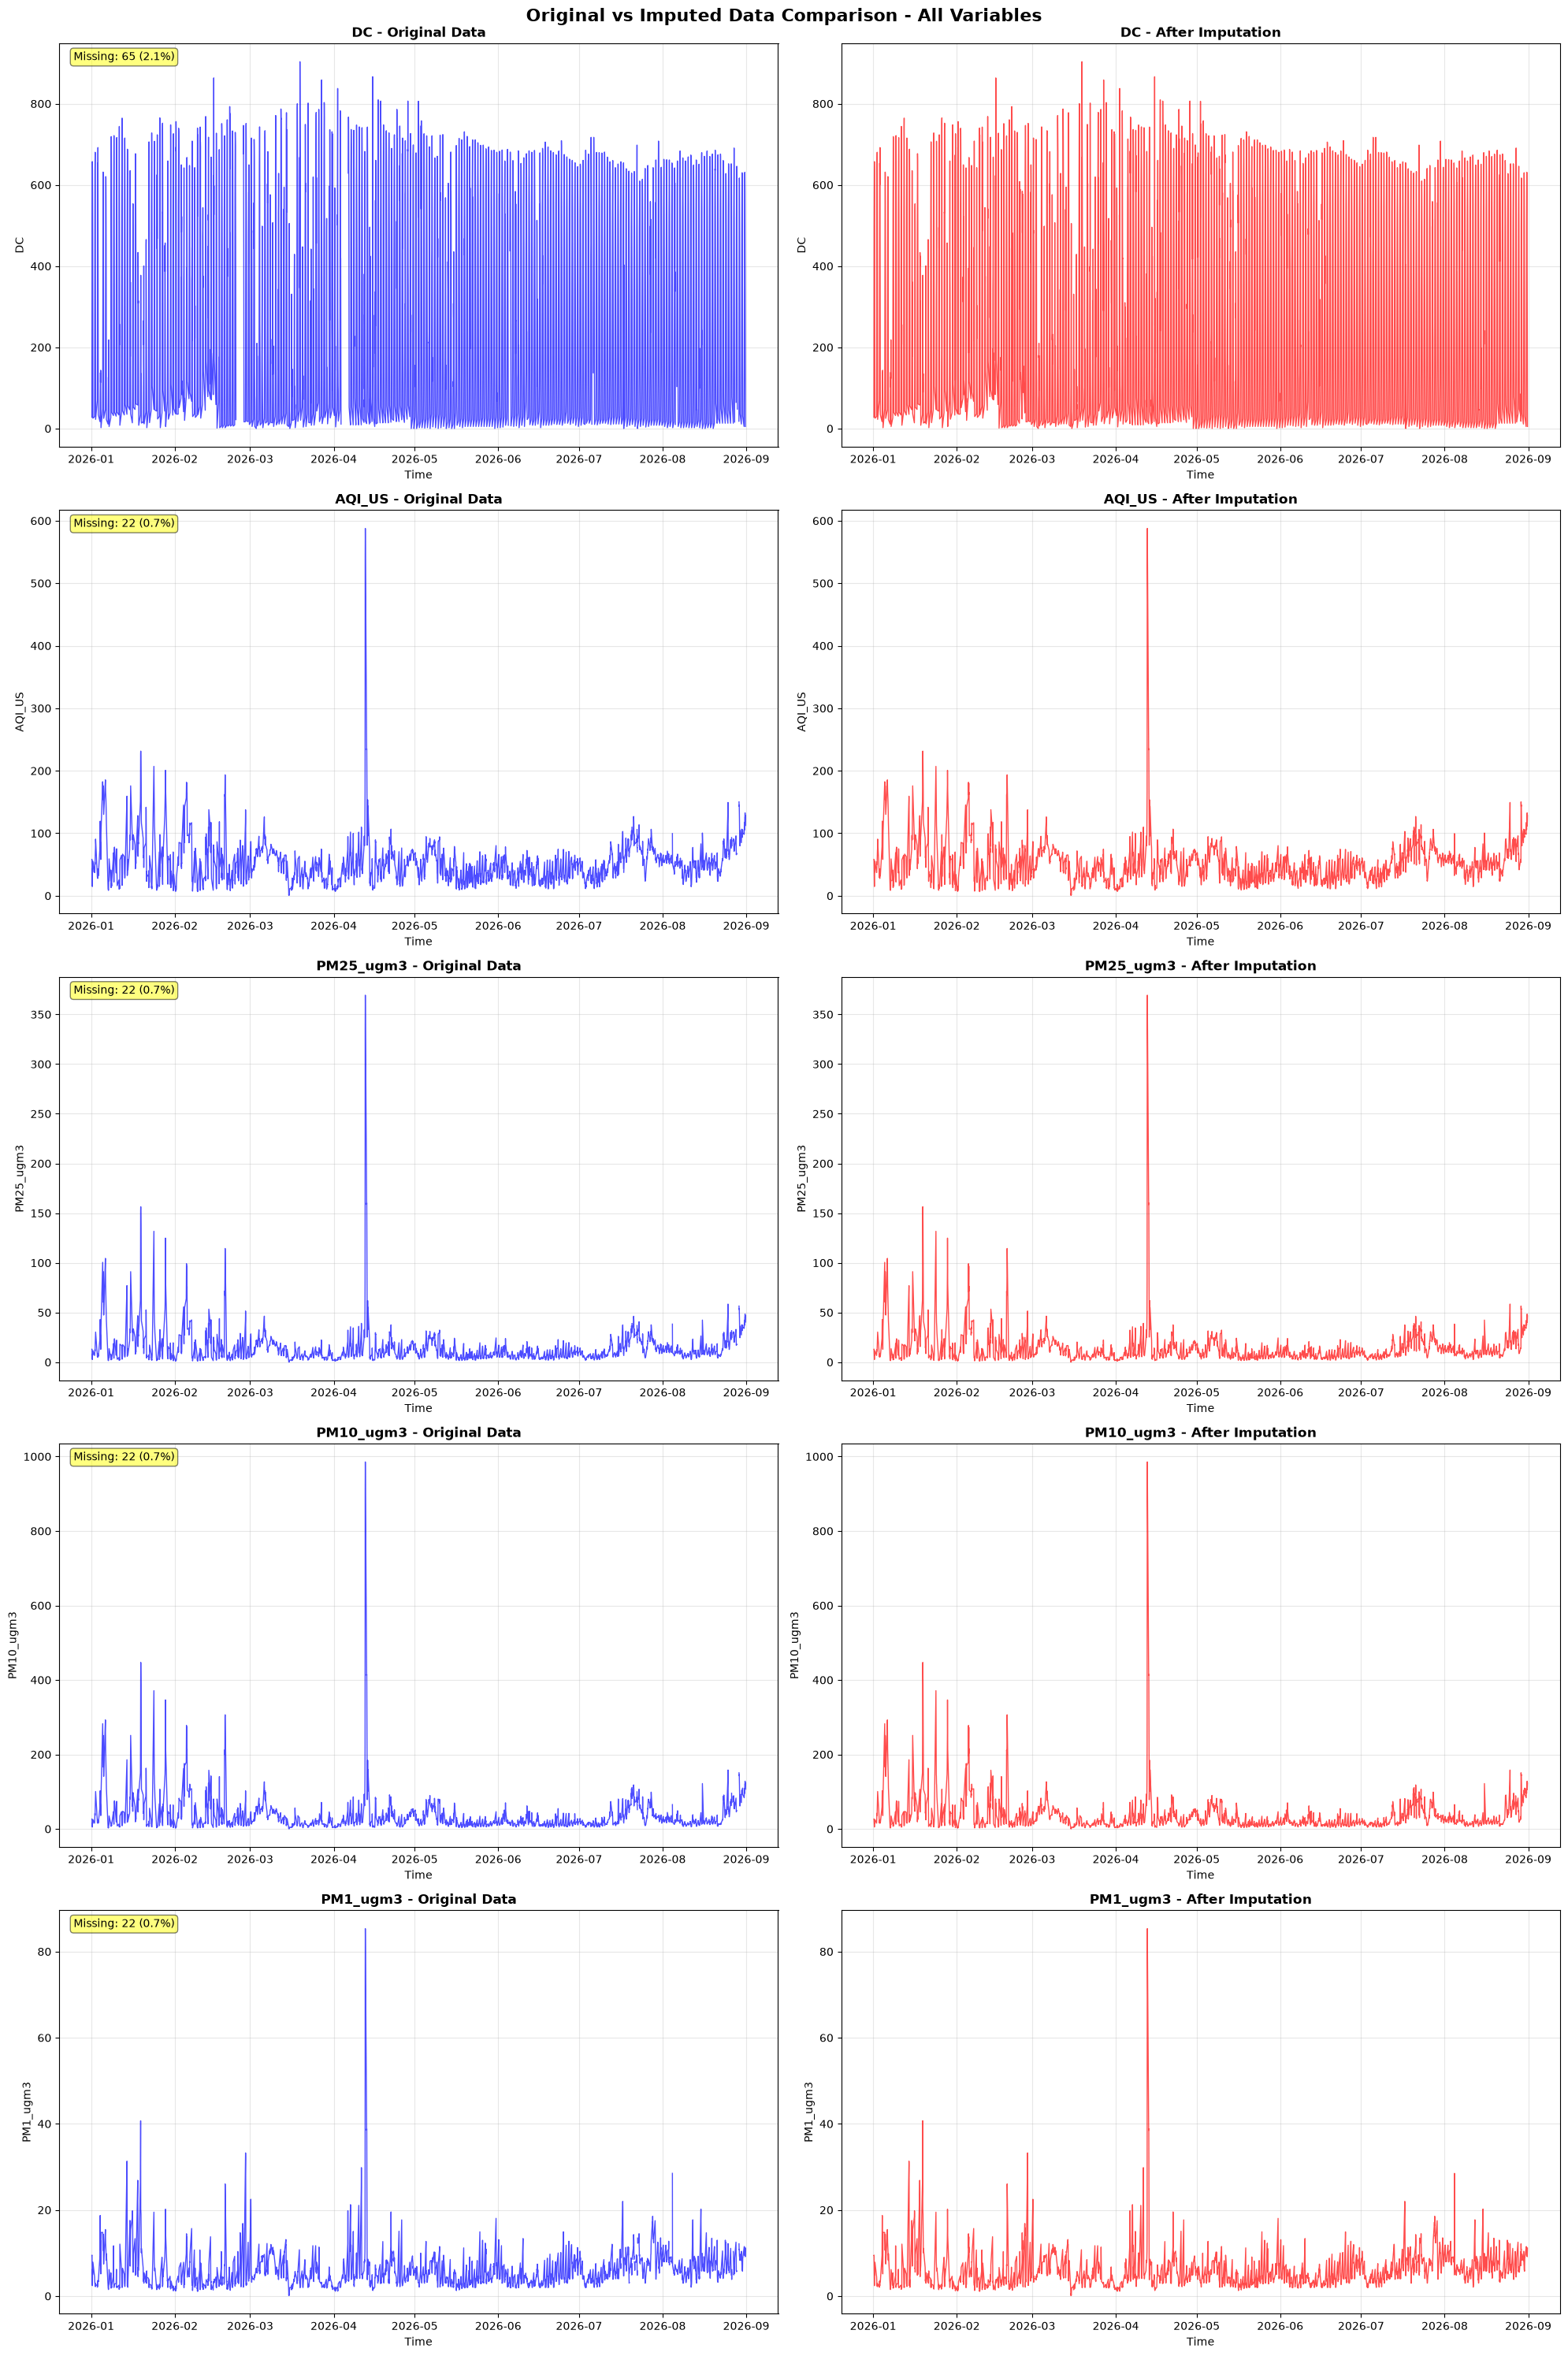

Saved combined grid plot: All_Variables_Original_vs_Imputed_Grid.png


In [19]:
numeric_columns = df_filtered.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns = [col for col in numeric_columns if col not in ['Hour_of_Day']]

columns_to_plot = [col for col in numeric_columns if df_filtered[col].isnull().sum() > 0]

print(f"Creating grid comparison plot for columns with imputed values: {columns_to_plot}")

n_rows = len(columns_to_plot)
n_subplot_cols = 2

fig, axes = plt.subplots(n_rows, n_subplot_cols, figsize=(20, 6*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(columns_to_plot):
    ax1 = axes[i, 0]
    ax1.plot(df_filtered.index, df_filtered[col], color="blue", alpha=0.7, linewidth=1)
    ax1.set_xlabel("Time")
    ax1.set_ylabel(col)
    ax1.set_title(f"{col} - Original Data", fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    missing_mask = df_filtered[col].isnull()
    if missing_mask.any():
        missing_count = missing_mask.sum()
        missing_percent = (missing_count / len(df_filtered)) * 100
        ax1.text(0.02, 0.98, f'Missing: {missing_count} ({missing_percent:.1f}%)',
                transform=ax1.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

    ax2 = axes[i, 1]
    ax2.plot(df_imputed.index, df_imputed[col], color="red", alpha=0.7, linewidth=1)
    ax2.set_xlabel("Time")
    ax2.set_ylabel(col)
    ax2.set_title(f"{col} - After Imputation", fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
    y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(y_min, y_max)
    ax2.set_ylim(y_min, y_max)

fig.suptitle('Original vs Imputed Data Comparison - All Variables', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.subplots_adjust(top=0.98)

filename = "All_Variables_Original_vs_Imputed_Grid.png"
plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"Saved combined grid plot: {filename}")

In [20]:
df_filtered.describe()

,DC,Solar_Radiation_Wm2,Outdoor_Temp_C,Dew_Point_C,Wind_Speed_ms,Wind_Dir_deg,Pressure_hPa,Humidity_pct,UV_Index,Wind_Gust_ms,Rain_mm,AQI_US,PM25_ugm3,PM10_ugm3,PM1_ugm3
count,3019.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3062.00000,3062.000000,3062.000000,3062.000000
mean,344.238495,356.596419,24.567502,13.983722,1.022091,180.097357,1013.751768,53.905667,3.080556,3.702732,5.284663,49.92188,13.279750,33.813248,5.595679
std,252.467498,264.070227,7.499429,6.456336,0.847384,58.749045,5.413240,14.030237,2.625351,2.201049,33.607698,33.53120,17.092922,47.305713,4.236273
min,0.000000,0.150000,6.842000,-0.883000,0.000000,1.000000,995.062000,8.000000,0.000000,0.000000,0.000000,0.80000,0.133000,0.400000,0.133000
25%,77.500000,102.291500,18.200000,9.373000,0.483000,138.917000,1011.148000,44.417000,0.448500,2.000000,0.000000,27.68725,5.004250,11.383000,3.017000
50%,366.500000,336.054500,24.237500,13.717000,0.792000,160.667000,1013.970000,53.417000,2.833000,3.100000,0.000000,44.15850,8.317000,19.092000,4.533000
75%,586.250000,597.918500,30.994000,19.269000,1.227000,221.354000,1017.074000,62.833000,5.333000,4.600000,0.000000,64.10450,16.217000,40.657750,7.017000
max,903.500000,948.000000,47.500000,28.225000,6.942000,359.000000,1027.798000,95.750000,12.000000,17.300000,402.000000,587.70000,369.383000,985.533000,85.317000


In [21]:
df_imputed.describe()

,DC,Solar_Radiation_Wm2,Outdoor_Temp_C,Dew_Point_C,Wind_Speed_ms,Wind_Dir_deg,Pressure_hPa,Humidity_pct,UV_Index,Wind_Gust_ms,Rain_mm,AQI_US,PM25_ugm3,PM10_ugm3,PM1_ugm3
count,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000,3084.000000
mean,343.002588,356.596419,24.567502,13.983722,1.022091,180.097357,1013.751768,53.905667,3.080556,3.702732,5.284663,49.931421,13.270596,33.780590,5.600538
std,252.291826,264.070227,7.499429,6.456336,0.847384,58.749045,5.413240,14.030237,2.625351,2.201049,33.607698,33.418913,17.034072,47.145981,4.223564
min,0.000000,0.150000,6.842000,-0.883000,0.000000,1.000000,995.062000,8.000000,0.000000,0.000000,0.000000,0.800000,0.133000,0.400000,0.133000
25%,76.500000,102.291500,18.200000,9.373000,0.483000,138.917000,1011.148000,44.417000,0.448500,2.000000,0.000000,27.767000,5.033000,11.417000,3.017000
50%,364.500000,336.054500,24.237500,13.717000,0.792000,160.667000,1013.970000,53.417000,2.833000,3.100000,0.000000,44.333000,8.391500,19.175000,4.561800
75%,584.500000,597.918500,30.994000,19.269000,1.227000,221.354000,1017.074000,62.833000,5.333000,4.600000,0.000000,63.983500,16.204250,40.550000,7.017000
max,903.500000,948.000000,47.500000,28.225000,6.942000,359.000000,1027.798000,95.750000,12.000000,17.300000,402.000000,587.700000,369.383000,985.533000,85.317000


In [ ]:
sns.set_palette("Blues")

imputed_columns = ['DC', 'AQI_US', 'PM25_ugm3', 'PM10_ugm3', 'PM1_ugm3']

valid_cols = [col for col in imputed_columns if col in df_filtered.columns]

n_cols = 3
n_rows = len(valid_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.tight_layout(pad=5)

for i, col in enumerate(valid_cols):
    ax = axes[i, 0]
    sns.histplot(df_filtered[col].dropna(), color='navy', label='Original', kde=True, ax=ax)
    sns.histplot(df_imputed[col], color='skyblue', label='Imputed', kde=True, ax=ax, alpha=0.5)
    ax.set_title(f"Histogram - {col}")
    ax.legend()

    ax = axes[i, 1]
    ax.plot(df_filtered.index, df_filtered[col], label='Original', color='navy', alpha=0.7)
    ax.plot(df_filtered.index, df_imputed[col], label='Imputed', color='skyblue', alpha=0.7)
    ax.set_title(f"Time Series - {col}")
    ax.set_xlabel("Time")
    ax.set_ylabel(col)
    ax.legend()

    roll_orig = df_filtered[col].rolling(window=24).mean()
    roll_imputed = df_imputed[col].rolling(window=24).mean()
    ax = axes[i, 2]
    ax.plot(df_filtered.index, roll_orig, label='Original Rolling', color='navy')
    ax.plot(df_filtered.index, roll_imputed, label='Imputed Rolling', color='skyblue', linestyle='dashed')
    ax.set_title(f"Rolling Mean - {col}")
    ax.set_xlabel("Time")
    ax.set_ylabel(f"{col} (Rolling Mean)")
    ax.legend()

plt.show()

## Save imputed data

In [ ]:
df_imputed.reset_index(inplace=True)
df_imputed.to_csv("../data/imputed_filtered_data.csv", index=False)
print(f"Saved imputed data. Shape: {df_imputed.shape}")

Saved imputed data. Shape: (3084, 16)
